In [1]:
import sys
sys.path.append("../src")
sys.path.insert(0, "/Users/bohaoli/Desktop/tuto/tuto_langchain/official/langchain-langgraph-langsmith/utils")

from utils import ppm, ppms, debug

In [2]:
# Load environment variables and set up auto-reload
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

<div class="dark-title" style="background:linear-gradient(90deg,#1e3a8a,#5b21b6); color:#f1f5f9; padding:20px 32px; border-radius:8px; width:97%;"><style>.dark-title strong{color:#fde047;}</style>

## 🎁 Multi-Agent Research System — 全栈整合

**一句话定位**:**所有零件拼起来** —— scoping + multi-agent research + report generation,完整的 deep research pipeline。

</div>

整体流程图:

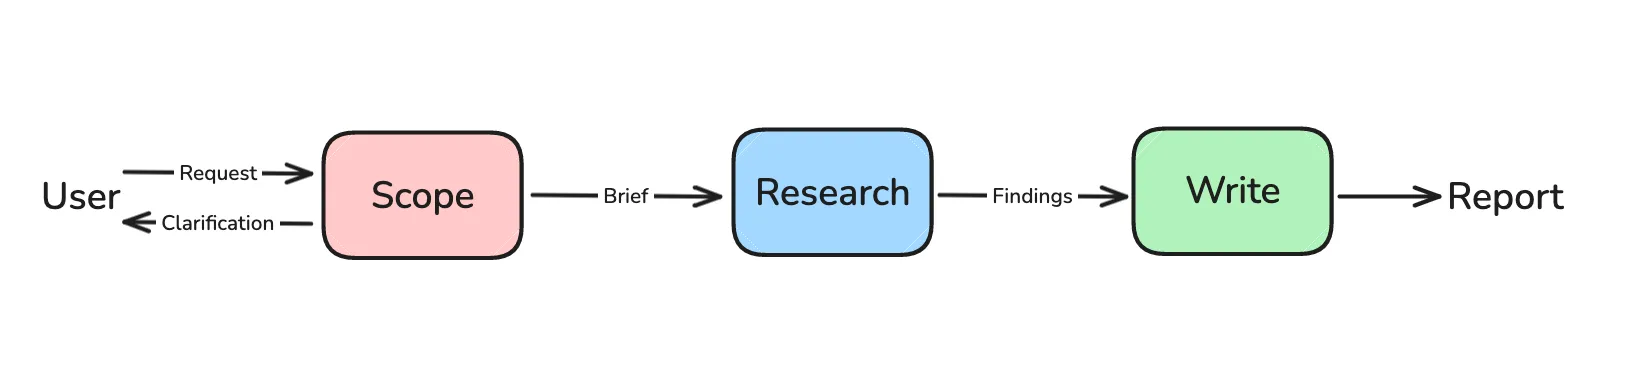

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**🧩 这一节做什么**

前面几节我们搭好了:

| 模块 | 来自 |
|------|------|
| **Research Scoping**(澄清 + brief 生成) | Lesson 1 |
| **Multi-Agent Research**(supervisor + 子 agent) | Lesson 4 |

**还差最后一块**:**Final Report Generation**(最终报告生成)。

本节把这三块整合,完成一个 **生产级 deep research 系统**。

</div>

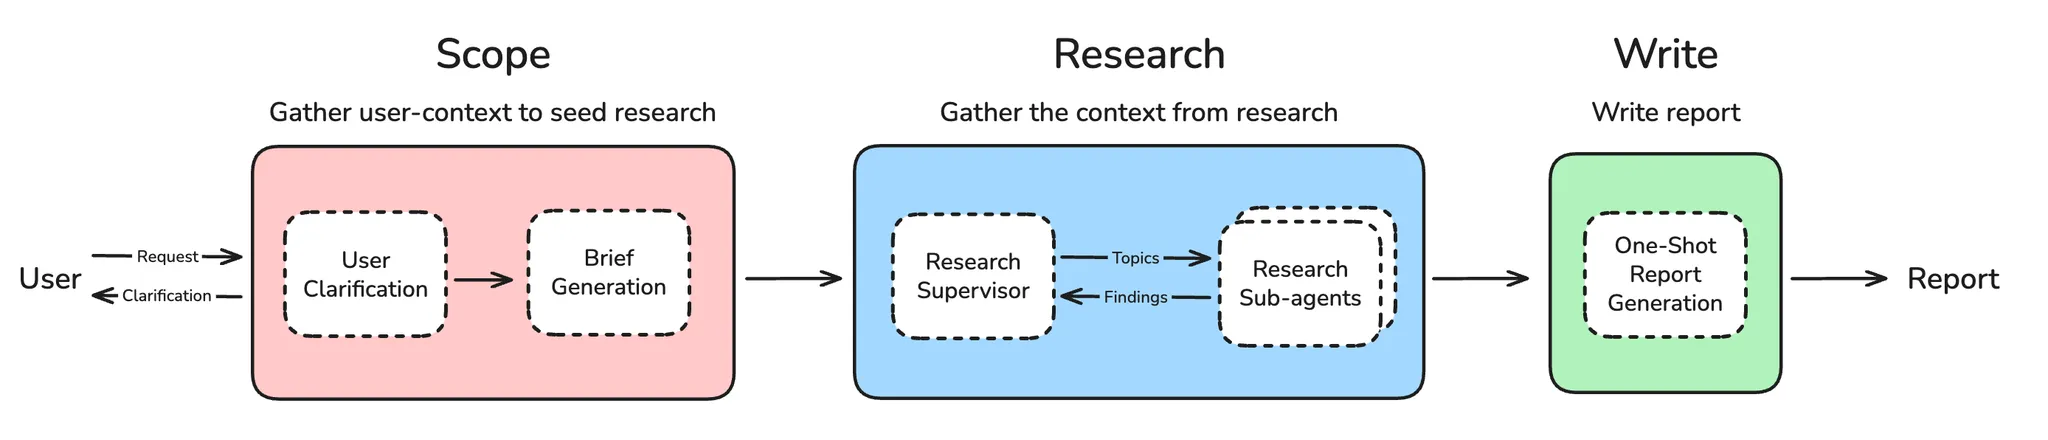

### 🤖 Agent — 直接复用前面的组件

**前面写的组件都能直接复用**(每个 notebook 用 `%%writefile` 存到 `src/` 目录,现在 import 进来即可)。

In [ ]:
%%writefile ../src/deep_research_from_scratch/research_agent_full.py

"""
Full Multi-Agent Research System

This module integrates all components of the research system:
- User clarification and scoping
- Research brief generation  
- Multi-agent research coordination
- Final report generation

The system orchestrates the complete research workflow from initial user
input through final report delivery.
"""

from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END

from deep_research_from_scratch.utils import get_today_str
from deep_research_from_scratch.prompts import final_report_generation_prompt
from deep_research_from_scratch.state_scope import AgentState, AgentInputState
from deep_research_from_scratch.research_agent_scope import (
    clarify_with_user,
    write_research_brief,
)
from deep_research_from_scratch.multi_agent_supervisor import supervisor_agent

# ===== Config =====

from langchain.chat_models import init_chat_model

writer_model = init_chat_model(
    model="openai:gpt-4.1", max_tokens=32000
)  # model="anthropic:claude-sonnet-4-6", max_tokens=64000

# ===== FINAL REPORT GENERATION =====

from deep_research_from_scratch.state_scope import AgentState


async def final_report_generation(state: AgentState):
    """
    Final report generation node.

    Synthesizes all research findings into a comprehensive final report
    """

    notes = state.get("notes", [])

    findings = "\n".join(notes)

    final_report_prompt = final_report_generation_prompt.format(
        research_brief=state.get("research_brief", ""),
        findings=findings,
        date=get_today_str(),
    )

    final_report = await writer_model.ainvoke(
        [HumanMessage(content=final_report_prompt)]
    )

    return {
        "final_report": final_report.content,
        "messages": ["Here is the final report: " + final_report.content],
    }


# ===== GRAPH CONSTRUCTION =====
# Build the overall workflow
deep_researcher_builder = StateGraph(AgentState, input_schema=AgentInputState)

# Add workflow nodes
deep_researcher_builder.add_node("clarify_with_user", clarify_with_user)
deep_researcher_builder.add_node("write_research_brief", write_research_brief)
deep_researcher_builder.add_node("supervisor_subgraph", supervisor_agent)
deep_researcher_builder.add_node("final_report_generation", final_report_generation)

# Add workflow edges
deep_researcher_builder.add_edge(START, "clarify_with_user")
deep_researcher_builder.add_edge("write_research_brief", "supervisor_subgraph")
deep_researcher_builder.add_edge("supervisor_subgraph", "final_report_generation")
deep_researcher_builder.add_edge("final_report_generation", END)

# Compile the full workflow
agent = deep_researcher_builder.compile()

Overwriting ../src/deep_research_from_scratch/research_agent_full.py


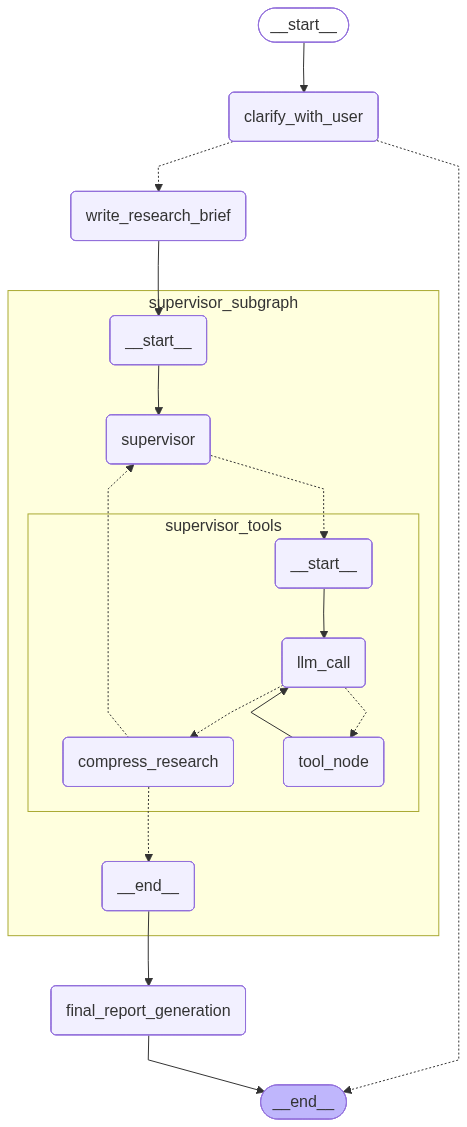

In [4]:
# Run the workflow
from utils import format_messages
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from deep_research_from_scratch.research_agent_full import deep_researcher_builder

checkpointer = InMemorySaver()
full_agent = deep_researcher_builder.compile(checkpointer=checkpointer)
display(Image(full_agent.get_graph(xray=True).draw_mermaid_png()))

### 🔁 Recursion Limit — 别让循环卡死

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

**🔑 LangGraph 默认 recursion limit = 25**

防止无限循环,LangGraph 默认 **每个图最多跑 25 步**。复杂的 deep research workflow **必须调高**。

引用 [LangGraph 文档](https://langchain-ai.github.io/langgraph/troubleshooting/errors/GRAPH_RECURSION_LIMIT/):recursion limit **统计图里每个 node 的执行次数**。

</div>

### 📊 本系统各阶段的步数估算

| 阶段 | 步数 |
|------|------|
| **单个 Research Agent** | 8-12 步(tool 调用 + 压缩) |
| **Multi-Agent Supervisor** | **每个派出的子 agent 额外几步** |
| **迭代研究** | supervisor 多轮研究填补空白 |
| **完整 workflow** | scoping + brief + supervision + report |

### 🎯 我们调到 50

设 `recursion_limit=50` 容纳:

- **复杂研究主题**(需要多轮研究)
- **并行子 agent 执行**
- **多次工具调用** 的深度研究
- **完整 workflow** 从 scoping 到 final report

→ 让 supervisor 能 **多轮研究填空白**,**全面覆盖** 复杂主题。

In [5]:
from langchain_core.messages import HumanMessage

thread = {"configurable": {"thread_id": "1", "recursion_limit": 50}}
result = await full_agent.ainvoke(
    {
        "messages": [
            HumanMessage(content="Compare Gemini to OpenAI Deep Research agents.")
        ]
    },
    config=thread,
)
format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Compare Gemini to OpenAI Deep Research agents.                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Could you please clarify what you mean by "Deep Research agents" from OpenAI? Are you referring to specific     │
│ research-focused AI models, tools like OpenAI's GPT-4, or something else? Additionally, are you interested in a │
│ technical comparison, use cases, performance, or another aspect?                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [6]:
result = await full_agent.ainvoke(
    {"messages": [HumanMessage(content="Yes the specific Deep Research products.")]},
    config=thread,
)

In [7]:
format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Compare Gemini to OpenAI Deep Research agents.                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Could you please clarify what you mean by "Deep Research agents" from OpenAI? Are you referring to specific     │
│ research-focused AI models, tools like OpenAI's GPT-4, or something else? Additionally, are you interested in a │
│ technical comparison, use cases, performance, or another aspect?                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Yes the specific Deep Research products.                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Thank you for clarifying that you are interested in a comparison between Gemini and OpenAI's specific Deep      │
│ Research products. I understand that you are seeking a comparative analysis of these research-focused AI        │
│ agents, likely in terms of their technical capabilities, use cases, and performance. I will now begin the       │
│ research process based on this scope.                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Here is the final report: # Comparative Analysis: Google Gemini AI Platform vs. OpenAI Deep Research Agents     │
│ (May 2026)                                                                                                      │
│                                                                                                                 │
│ ## Introduction                                                                                                 │
│                                                                                                                 │
│ This report provides a comprehensive comparative analysis of Google's Gemini AI platform and OpenAI's           │
│ officially released Deep Research products as of May 2026. The analysis focuses on technical capabilities, core │
│ features, use cases, performance benchmarks, integration options, pricing structures, and other                 │
│ decision-critical dimensions. Official sources are prioritized throughout, enabling an informed, nuanced        │
│ understanding of each platform’s strengths, appropriate use cases, and current limitations.                     │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## Overview of Google Gemini AI Platform                                                                        │
│                                                                                                                 │
│ ### Platform Scope and Architecture                                                                             │
│                                                                                                                 │
│ Gemini is Google's flagship family of multimodal generative AI models, developed by DeepMind and Google         │
│ Research. Gemini models are architected on a large-scale transformer with Mixture of Experts (MoE) layers,      │
│ allowing the system to selectively activate expert subnetworks for efficient, high-performance reasoning over   │
│ vast parameter spaces. Key advancements in the Gemini 2 and 3 series include:                                   │
│                                                                                                                 │
│ - **Native multimodality:** Full support for simultaneous text, images, audio, video, and code across shared    │
│ attention spaces.                                                                                               │
│ - **Context window:** Up to 2 million tokens in flagship releases (e.g., Gemini 3.1 Pro), enabling ingestion    │
│ and comprehension of large document sets, extended chat histories, and complex codebases in a single pass.      │
│ - **Reasoning capabilities:** “Thinking mode” with configurable depth (thinkingBudget parameter), supporting    │
│ multi-step internal planning before output is generated.                                                        │
│ - **Agentic tool use:** Models can natively call APIs, browse the web, execute code, and perform structured     │
│ workflows through developer-defined function interfaces.[1][2][3][4][5][6]                                      │
│                                                                                                                 │
│ ### Research-Focused Features                                                                                   │
│                                                                                                                 │
│ Gemini has developed “Deep Research”—an agentic system 

In [8]:
from rich.markdown import Markdown
Markdown(result["final_report"])

Comparative Analysis: Google Gemini AI Platform vs. OpenAI Deep Research Agents (May 2026)             

Introduction                                                                                                       

This report provides a comprehensive comparative analysis of Google's Gemini AI platform and OpenAI's officially   
released Deep Research products as of May 2026. The analysis focuses on technical capabilities, core features, use 
cases, performance benchmarks, integration options, pricing structures, and other decision-critical dimensions.    
Official sources are prioritized throughout, enabling an informed, nuanced understanding of each platform’s        
strengths, appropriate use cases, and current limitations.                                                         

-------------------------------------------------------------------------------------------------------------------

Overview of Google Gemini AI Platform                                                                              

Platform Scope and Architecture                                                                                    

Gemini is Google's flagship family of multimodal generative AI models, developed by DeepMind and Google Research.  
Gemini models are architected on a large-scale transformer with Mixture of Experts (MoE) layers, allowing the      
system to selectively activate expert subnetworks for efficient, high-performance reasoning over vast parameter    
spaces. Key advancements in the Gemini 2 and 3 series include:                                                     

 • Native multimodality: Full support for simultaneous text, images, audio, video, and code across shared attention
   spaces.                                                                                                         
 • Context window: Up to 2 million tokens in flagship releases (e.g., Gemini 3.1 Pro), enabling ingestion and      
   comprehension of large document sets, extended chat histories, and complex codebases in a single pass.          
 • Reasoning capabilities: “Thinking mode” with configurable depth (thinkingBudget parameter), supporting          
   multi-step internal planning before output is generated.                                                        
 • Agentic tool use: Models can natively call APIs, browse the web, execute code, and perform structured workflows 
   through developer-defined function interfaces.[1][2][3][4][5][6]                                                

Research-Focused Features                                                                                          

Gemini has developed “Deep Research”—an agentic system that autonomously executes multi-step research workflows    
across hundreds of online and proprietary sources, synthesizing multi-page, cited reports. Deep Research can access
and analyze content not only from the public web, but also from files in Google Drive, Gmail, and Chat.[7][8][9]   

Prominent research tools and integrations include:                                                                 

 • Gemini Deep Research: Automated cited report synthesis with multi-stage planning, iterative retrieval, and      
   interactive report refinement.                                                                                  
 • NotebookLM: Personal knowledge agent that reasons over user-uploaded data.                                      
 • Project Mariner: Browser-based multi-agent automation.                                                          
 • Export to Google Docs: Deep Research outputs and summaries can be exported and collaboratively edited.          
 • Agent plugins for Workspace and Google AI Studio: Seamless embedding in productivity workflows.                 

Technical Specifications                                                                                           

 • Model lineup: Gemini 2.5 Pro (1M context tokens), Ge

执行 trace 看 [这里](https://smith.langchain.com/public/86ebdc25-4595-4040-be1e-a8e30052786b/r)。

### 🚀 LangGraph Studio

跟之前一样,可视化 agent。

整个课程里 `%%writefile` 到 `src/deep_research_from_scratch/` 的文件 **构成完整应用**:

```
deep_research_from_scratch/
├── src/deep_research_from_scratch/
│   ├── state.py          # State 定义
│   ├── scope_research.py # Scoping workflow
│   ├── prompts.py        # Prompt 模板
│   └── ...
├── notebooks/            # 开发 notebook
├── pyproject.toml        # 依赖
└── langgraph.json        # LangGraph 配置
```

`langgraph.json` 里选 `research_agent_full`:

```json
"research_agent_full": "./src/deep_research_from_scratch/research_agent_full.py:agent"
```

启动:

```bash
uvx --refresh --from "langgraph-cli[inmem]" --with-editable . --python 3.11 langgraph dev --allow-blocking
```

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

## ✨ 整门课带走

**Deep Research = 4 步标准 pipeline**:

| # | 阶段 | 来自 |
|---|------|------|
| 1 | **Scoping** — 澄清 + brief 生成 | Lesson 1 |
| 2 | **Research** — 单 agent 工具循环 + 压缩 | Lesson 2 / 3 |
| 3 | **Supervision** — multi-agent 派单与协调 | Lesson 4 |
| 4 | **Report** — 综合 findings 写最终报告 | 本节 |

🎯 **关键设计哲学**:

1. **Context engineering > prompt engineering** — 怎么管 context 比怎么写 prompt 更重要
2. **能不派子 agent 就不派** — multi-agent 是 last resort,不是默认
3. **每一步都要测** — LangSmith eval 贯穿全程
4. **recursion_limit 显式设大** — 不然复杂任务会被 25 步 cap 掉

</div>